# Phase 2 - Train Spark MLlib Baselines on Real BTS Outcomes

This notebook demonstrates the model-training design using January 2024 Gold features. It compares Logistic Regression and Random Forest baselines through a reusable Spark MLlib pipeline.

Production counterpart: `spark_jobs/train_mllib_experiments.py`.

The current random split is an initial diagnostic only. The final evaluation must use a chronological split after the dataset expands beyond one month.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler

PROJECT_ROOT = Path("/workspace")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from spark_jobs.build_gold_features import CATEGORICAL_FEATURES, NUMERIC_FEATURES
from spark_jobs.common import create_spark_session, load_settings, s3a_uri

YEAR, MONTH = 2024, 1
RUN_TRAINING = False  # Set True to rerun the production experiment job from the next cell.
METRICS_PATH = Path("/workspace/data/local_cache/model_metrics/january_2024_mllib.json")

print("Categorical features:", CATEGORICAL_FEATURES)
print("Numeric features:", NUMERIC_FEATURES)

Categorical features: ['origin', 'reporting_airline']
Numeric features: ['scheduled_departure_hour_local', 'distance_miles', 'day_of_week', 'day_of_month', 'temperature_c_avg', 'wind_speed_kts_max', 'wind_gust_kts_max', 'precipitation_mm_sum', 'surface_pressure_pa_avg', 'total_cloud_cover_avg', 'cape_j_kg_max']


## Visible Spark MLlib Pipeline

Categorical columns are indexed and one-hot encoded. Numeric and encoded categorical columns are assembled into a single feature vector before fitting each classifier.

In [2]:
def build_pipeline(classifier):
    indexers = [
        StringIndexer(inputCol=column, outputCol=f"{column}_index", handleInvalid="keep")
        for column in CATEGORICAL_FEATURES
    ]
    encoded_columns = [f"{column}_encoded" for column in CATEGORICAL_FEATURES]
    encoder = OneHotEncoder(
        inputCols=[f"{column}_index" for column in CATEGORICAL_FEATURES],
        outputCols=encoded_columns,
        handleInvalid="keep",
    )
    assembler = VectorAssembler(
        inputCols=NUMERIC_FEATURES + encoded_columns,
        outputCol="features",
        handleInvalid="error",
    )
    return Pipeline(stages=[*indexers, encoder, assembler, classifier])

experiments = [
    {"run_name": "logistic_regression_reg_0_01", "classifier": "LogisticRegression", "regParam": 0.01},
    {"run_name": "logistic_regression_reg_0_05", "classifier": "LogisticRegression", "regParam": 0.05},
    {"run_name": "logistic_regression_reg_0_10", "classifier": "LogisticRegression", "regParam": 0.10},
    {"run_name": "random_forest_trees_20_depth_6", "classifier": "RandomForestClassifier", "numTrees": 20, "maxDepth": 6},
    {"run_name": "random_forest_trees_40_depth_8", "classifier": "RandomForestClassifier", "numTrees": 40, "maxDepth": 8},
]
print("Configured MLlib experiments:")
for experiment in experiments:
    print(" -", experiment)

Configured MLlib experiments:
 - {'run_name': 'logistic_regression_reg_0_01', 'classifier': 'LogisticRegression', 'regParam': 0.01}
 - {'run_name': 'logistic_regression_reg_0_05', 'classifier': 'LogisticRegression', 'regParam': 0.05}
 - {'run_name': 'logistic_regression_reg_0_10', 'classifier': 'LogisticRegression', 'regParam': 0.1}
 - {'run_name': 'random_forest_trees_20_depth_6', 'classifier': 'RandomForestClassifier', 'numTrees': 20, 'maxDepth': 6}
 - {'run_name': 'random_forest_trees_40_depth_8', 'classifier': 'RandomForestClassifier', 'numTrees': 40, 'maxDepth': 8}


## Run or Load Verified Experiment Metrics

The production job trains all five pipelines, computes AUC, accuracy, F1, weighted metrics, and the confusion matrix, then saves a small JSON report for presentation.

In [3]:
if RUN_TRAINING:
    import subprocess
    subprocess.run(
        ["python", "-m", "spark_jobs.train_mllib_experiments", "--year", str(YEAR), "--month", str(MONTH)],
        cwd="/workspace",
        check=True,
    )

assert METRICS_PATH.exists(), "Run the production MLlib experiment job first."
metrics_df = pd.DataFrame(json.loads(METRICS_PATH.read_text()))
display(metrics_df[
    ["run_name", "auc", "accuracy", "f1", "positive_precision", "positive_recall", "true_positive", "false_negative"]
].sort_values("auc", ascending=False))

,run_name,auc,accuracy,f1,positive_precision,positive_recall,true_positive,false_negative
4,random_forest_trees_40_depth_8,0.700825,0.732766,0.619955,0.772727,0.000585,17,29058
0,logistic_regression_reg_0_01,0.690043,0.750228,0.686294,0.647796,0.144041,4188,24887
1,logistic_regression_reg_0_05,0.684267,0.743423,0.661397,0.660455,0.082889,2410,26665
2,logistic_regression_reg_0_10,0.679896,0.738136,0.642825,0.651577,0.044058,1281,27794
3,random_forest_trees_20_depth_6,0.677954,0.732656,0.619609,0.000000,0.000000,0,29075


<Axes: title={'center': 'Positive-class recall exposes default-threshold weakness'}, ylabel='run_name'>

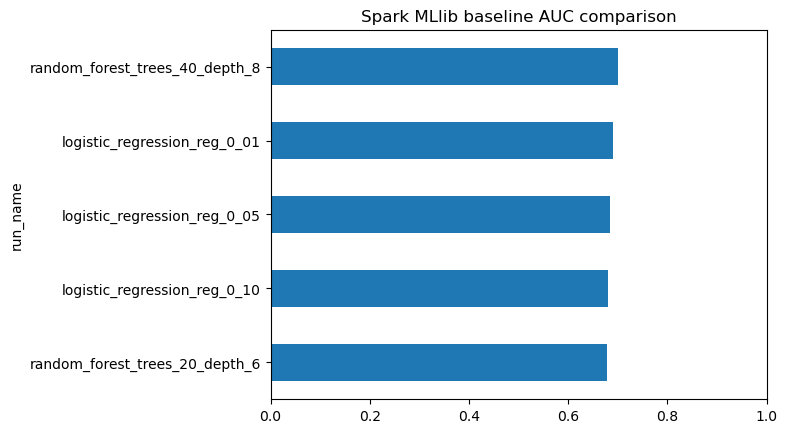

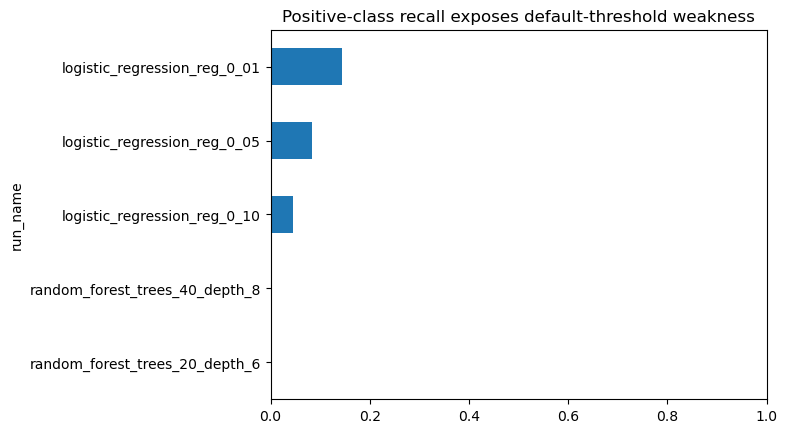

In [4]:
metrics_df.sort_values("auc").plot.barh(
    x="run_name", y="auc", xlim=(0.0, 1.0), legend=False,
    title="Spark MLlib baseline AUC comparison",
)
metrics_df.sort_values("positive_recall").plot.barh(
    x="run_name", y="positive_recall", xlim=(0.0, 1.0), legend=False,
    title="Positive-class recall exposes default-threshold weakness",
)

## Diagnostic Conclusion

The baseline models are intentionally presented as diagnostics, not final-quality predictors. AUC is informative, but default thresholds miss most disruption positives because the classes are imbalanced. The next modeling pass must add class weighting, threshold tuning, and chronological evaluation.